In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
file_path = '/content/drive/MyDrive/Project/amazon_ecommerce_1M.csv'
df = pd.read_csv(file_path)

display(df.head())

,user_id,product_id,category,subcategory,brand,price,discount,final_price,rating,review_count,stock,seller_id,seller_rating,purchase_date,shipping_time_days,location,device,payment_method,is_returned,delivery_status
0,U356787,P39256,Electronics,Mobile,H&M,33090.51,10.46,29629.31,4.9,43,71,S2679,4.3,2025-03-04,6,Bangalore,Tablet,UPI,True,Returned
1,U198246,P38657,Sports,Outdoor,Samsung,9368.97,5.32,8870.73,3.9,13,119,S9279,4.9,2025-12-12,1,Delhi,Tablet,UPI,True,Returned
2,U539898,P38893,Sports,Fitness,H&M,14756.85,26.00,10919.43,4.2,46,229,S5557,4.9,2024-04-25,1,Chennai,Mobile App,Credit Card,True,Returned
3,U325772,P54118,Beauty,Makeup,Sony,668.83,24.81,502.91,3.8,6,52,S2519,3.1,2025-12-18,2,Mumbai,Web,UPI,False,In Transit
4,U865179,P70217,Home,Decor,Sony,10881.29,48.63,5589.58,4.0,48,274,S3045,2.6,2024-05-16,5,Delhi,Web,UPI,False,Delayed


##**Data Preprocessing**

In [ ]:
# Convert date
df['purchase_date'] = pd.to_datetime(df['purchase_date'])

# Create new features
df['year'] = df['purchase_date'].dt.year
df['month'] = df['purchase_date'].dt.month

df['revenue'] = df['final_price']

# Discount value
df['discount_value'] = df['price'] - df['final_price']

#**ANALYSIS**

# **Revenue Overview**

In [ ]:
total_revenue = df['revenue'].sum()
avg_order_value = df['revenue'].mean()

print(total_revenue, avg_order_value)

df.groupby('category')['revenue'].sum().sort_values(ascending=False)

9938876984.9 9938.8769849


,revenue
category,
Electronics,6.579048e+09
Home,1.529978e+09
Sports,1.124849e+09
Beauty,3.759517e+08
Clothing,3.290504e+08


# **Customer Behavior**

In [ ]:
customer_stats = df.groupby('user_id').agg({
    'revenue': 'sum',
    'user_id': 'count'
}).rename(columns={'user_id': 'frequency'})

In [ ]:
distinct_user_count = df['user_id'].nunique()
print(f"Distinct User ID Count: {distinct_user_count}")

Distinct User ID Count: 603815


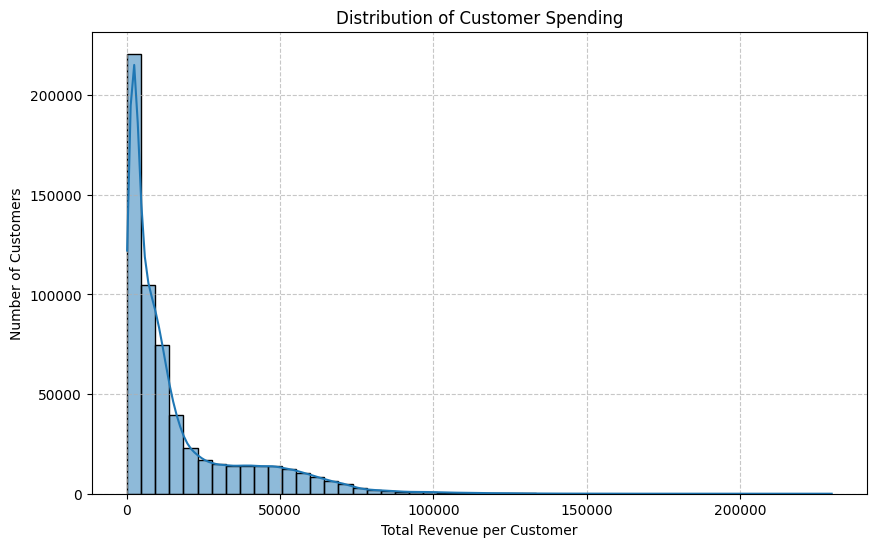

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(customer_stats['revenue'], bins=50, kde=True)
plt.title('Distribution of Customer Spending')
plt.xlabel('Total Revenue per Customer')
plt.ylabel('Number of Customers')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Top 10 users by total revenue
top_revenue_users = customer_stats.sort_values(by='revenue', ascending=False).head(10)
print('Top 10 Users by Total Revenue:')
display(top_revenue_users)

Top 10 Users by Total Revenue:


,revenue,frequency
user_id,,
U434268,229853.10,5
U902761,207234.79,7
U454661,199875.10,7
U384705,195983.73,5
U706383,195247.80,4
U978563,192137.94,5
U746513,188840.50,4
U224240,186945.13,4
U471344,181008.08,5


In [ ]:
# Top 10 users by purchase frequency
top_frequency_users = customer_stats.sort_values(by='frequency', ascending=False).head(10)
print('\nTop 10 Users by Purchase Frequency:')
display(top_frequency_users)


Top 10 Users by Purchase Frequency:


,revenue,frequency
user_id,,
U577752,70398.86,9
U272481,123797.04,9
U380466,37716.99,9
U678771,46417.85,9
U357853,128155.33,9
U320492,133981.41,8
U503937,79363.75,8
U963276,103364.03,8
U997906,33966.88,8


# **Returns Analysis**

In [ ]:
return_rate = df['is_returned'].mean()

df.groupby('category')['is_returned'].mean().sort_values(ascending=False)

,is_returned
category,
Beauty,0.117561
Clothing,0.117363
Sports,0.116460
Home,0.115841
Electronics,0.112734


# **Return Frequency Monetary (RFM) Analysis**

In [ ]:
# Set reference date
reference_date = df['purchase_date'].max()

In [ ]:
# RFM Computation
rfm = df.groupby('user_id').agg({
    'purchase_date': lambda x: (reference_date - x.max()).days,
    'user_id': 'count',
    'revenue': 'sum'
})

rfm.columns = ['recency', 'frequency', 'monetary']

In [ ]:
# Customer segmentation
rfm['R_score'] = pd.qcut(rfm['recency'], 4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['monetary'], 4, labels=[1,2,3,4])

rfm['RFM_score'] = rfm[['R_score','F_score','M_score']].sum(axis=1)

In [ ]:
# Top 10 customers by RFM_score
top_rfm_score_customers = rfm.sort_values(by='RFM_score', ascending=False).head(10)
print('Top 10 Customers by RFM Score:')
display(top_rfm_score_customers)

Top 10 Customers by RFM Score:


,recency,frequency,monetary,R_score,F_score,M_score,RFM_score
user_id,,,,,,,
U222086,75,3,59166.05,4,4,4,12
U222078,75,4,73109.66,4,4,4,12
U929774,19,2,44892.62,4,4,4,12
U222117,99,4,62124.45,4,4,4,12
U222105,112,3,82024.98,4,4,4,12
U222102,20,7,35138.87,4,4,4,12
U222100,24,5,37074.22,4,4,4,12
U929754,109,2,49715.62,4,4,4,12
U660080,0,3,48132.02,4,4,4,12


In [ ]:
# Bottom 10 customers by RFM_score
bottom_rfm_score_customers = rfm.sort_values(by='RFM_score', ascending=True).head(10)
print('\nBottom 10 Customers by RFM Score:')
display(bottom_rfm_score_customers)


Bottom 10 Customers by RFM Score:


,recency,frequency,monetary,R_score,F_score,M_score,RFM_score
user_id,,,,,,,
U320284,567,1,2819.27,1,1,1,3
U320243,478,1,1154.98,1,1,1,3
U320233,619,1,1090.51,1,1,1,3
U320229,698,1,749.57,1,1,1,3
U320318,534,1,2473.07,1,1,1,3
U100045,653,1,2068.84,1,1,1,3
U320396,711,1,2327.19,1,1,1,3
U320312,560,1,390.02,1,1,1,3
U320307,556,1,202.83,1,1,1,3


# **Seller Performance**

In [ ]:
df.groupby('seller_id').agg({
    'revenue': 'sum',
    'seller_rating': 'mean',
    'is_returned': 'mean'
}).sort_values(by='revenue', ascending=False)

,revenue,seller_rating,is_returned
seller_id,,,
S7740,1891954.53,3.717969,0.132812
S2013,1810498.08,3.737879,0.128788
S4656,1791917.86,3.763281,0.148438
S6442,1786697.11,3.626271,0.118644
S2478,1776687.77,3.830000,0.150000
...,...,...,...
S3178,594928.08,3.655319,0.106383
S9141,577295.76,3.811340,0.123711
S2343,568132.44,3.753165,0.075949


# **Discount Effect**

In [ ]:
df[['discount', 'revenue']].corr()

,discount,revenue
discount,1.000000,-0.289594
revenue,-0.289594,1.000000


In [ ]:
# Top 5 categories by revenue
print("Top 5 Categories by Revenue:")
display(df.groupby('category')['revenue'].sum().sort_values(ascending=False).head(5))

Top 5 Categories by Revenue:


,revenue
category,
Electronics,6.579048e+09
Home,1.529978e+09
Sports,1.124849e+09
Beauty,3.759517e+08
Clothing,3.290504e+08


In [ ]:
# Overall return rate
overall_return_rate = df['is_returned'].mean()
print(f"\nOverall Return Rate: {overall_return_rate:.4f}")


Overall Return Rate: 0.1160


In [ ]:
# Summary of RFM (first 5 rows)
print("\nSummary of RFM (first 5 rows):")
display(rfm.head())


Summary of RFM (first 5 rows):


,recency,frequency,monetary,R_score,F_score,M_score,RFM_score
user_id,,,,,,,
U100001,194,2,7551.46,3,3,2,8
U100003,514,3,12966.04,1,4,3,8
U100004,322,1,66406.56,2,1,4,7
U100005,451,1,816.17,2,1,1,4
U100009,174,1,9374.64,3,1,3,7


**Is Electronics generatinghigh revenue because of volume, or
because of high prices?**

In [ ]:
df.groupby('category').agg({
    'revenue': ['sum', 'mean'],
    'product_id': 'count'
})

revenue               product_id
                      sum          mean      count
category                                          
Beauty       3.759517e+08   1886.105344     199327
Clothing     3.290504e+08   1646.701317     199824
Electronics  6.579048e+09  32888.991008     200038
Home         1.529978e+09   7614.784037     200922
Sports       1.124849e+09   5627.369187     199889

**Which category is driving returns?**

In [ ]:
df.groupby('category')['is_returned'].mean().sort_values(ascending=False)

,is_returned
category,
Beauty,0.117561
Clothing,0.117363
Sports,0.116460
Home,0.115841
Electronics,0.112734


# **Customer Segmentation**

In [ ]:
def segment_customer(score):
    if score >= 10:
        return 'High Value'
    elif score >= 7:
        return 'Loyal'
    elif score >= 5:
        return 'Potential'
    else:
        return 'Low Value'

rfm['segment'] = rfm['RFM_score'].apply(segment_customer)

In [ ]:
rfm['segment'].value_counts()

,count
segment,
Loyal,226314
Potential,151067
High Value,149329
Low Value,77105


In [ ]:
rfm.groupby('segment')['monetary'].mean()

,monetary
segment,
High Value,34264.217886
Low Value,2153.316611
Loyal,16101.232399
Potential,6700.800345


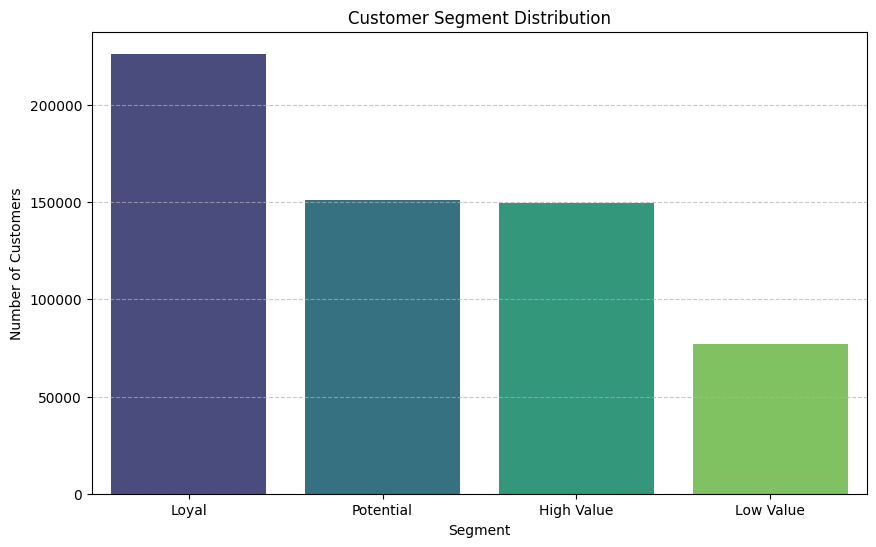

In [ ]:
segment_counts = rfm['segment'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=segment_counts.index, y=segment_counts.values, hue=segment_counts.index, palette='viridis', legend=False)
plt.title('Customer Segment Distribution')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Revenue contribution by customer segment**

In [ ]:
segment_revenue = rfm.groupby('segment')['monetary'].agg(
    customers='count',
    total_revenue='sum',
    avg_revenue='mean'
)

segment_revenue['revenue_contribution_%'] = (
    segment_revenue['total_revenue']
    / segment_revenue['total_revenue'].sum()
) * 100

segment_revenue = segment_revenue.sort_values(
    by='total_revenue',
    ascending=False
)

print(segment_revenue)

            customers  total_revenue   avg_revenue  revenue_contribution_%
segment                                                                   
High Value     149329   5.116641e+09  34264.217886               51.481082
Loyal          226314   3.643934e+09  16101.232399               36.663441
Potential      151067   1.012270e+09   6700.800345               10.184952
Low Value       77105   1.660315e+08   2153.316611                1.670526


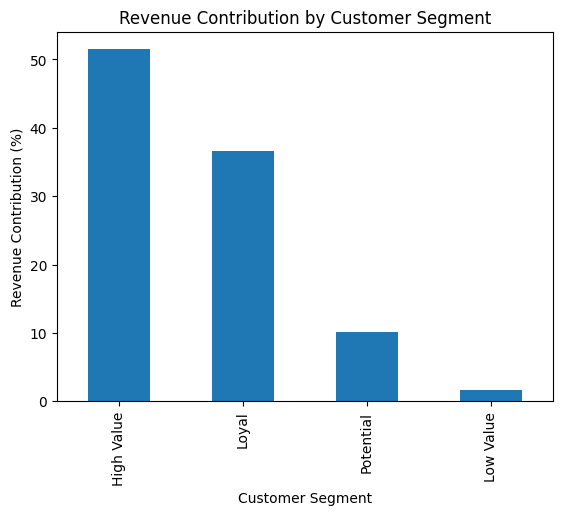

In [ ]:
segment_revenue['revenue_contribution_%'].plot(
    kind='bar'
)

plt.title('Revenue Contribution by Customer Segment')
plt.ylabel('Revenue Contribution (%)')
plt.xlabel('Customer Segment')
plt.show()

In [ ]:
df.groupby('device')['revenue'].sum().sort_values(ascending=False)

,revenue
device,
Mobile App,3.318986e+09
Web,3.318191e+09
Tablet,3.301700e+09


In [ ]:
df.groupby('device')['is_returned'].mean()

,is_returned
device,
Mobile App,0.115991
Tablet,0.116665
Web,0.115315


**Shipping Time vs Return Rate**

In [ ]:
shipping_returns = (
    df.groupby('shipping_time_days')
      ['is_returned']
      .mean()
)

print(shipping_returns)

shipping_time_days
1    0.106708
2    0.105741
3    0.105000
4    0.105720
5    0.106169
6    0.206716
Name: is_returned, dtype: float64


**Revenue Trend Analysis**

,revenue
purchase_date,
2024-03,1.388802e+07
2024-04,4.096292e+08
2024-05,4.207856e+08
2024-06,4.051715e+08
2024-07,4.217882e+08
2024-08,4.202220e+08
2024-09,4.039997e+08
2024-10,4.235672e+08
2024-11,4.118936e+08


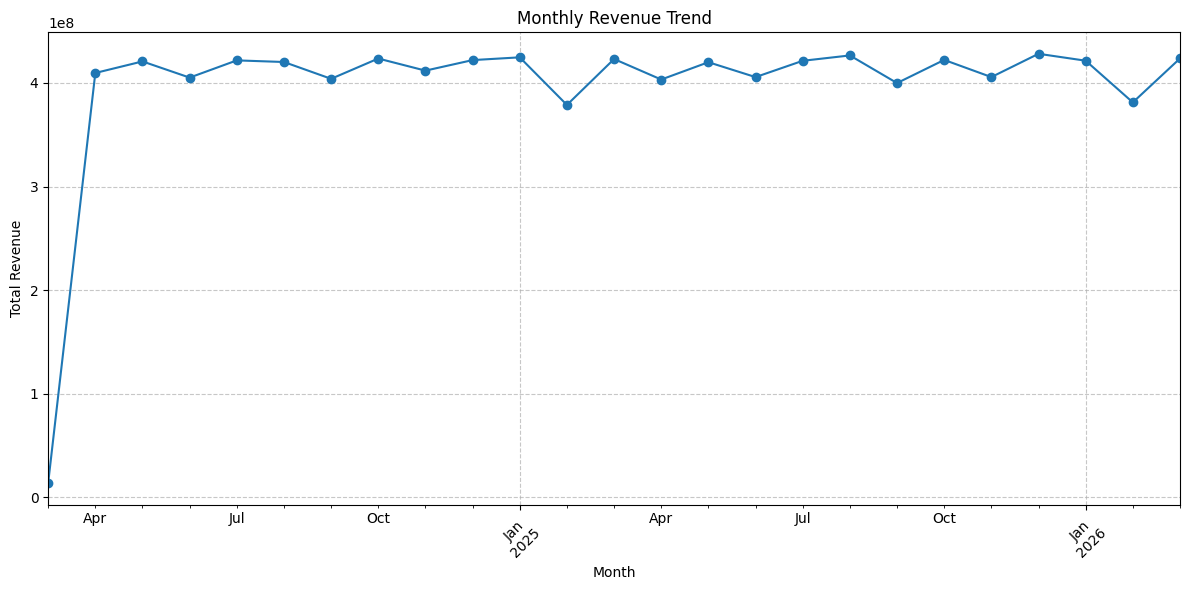

In [ ]:
monthly_revenue = (
    df.groupby(df['purchase_date'].dt.to_period('M'))['revenue']
      .sum()
)

display(monthly_revenue)

plt.figure(figsize=(12, 6))
monthly_revenue.plot(kind='line', marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()